In [32]:
import requests as req
from bs4 import BeautifulSoup as B
url = 'https://www.theeducatedbarfly.com/winter-daiquiri/'
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'}
resp = req.get(url, headers=header)
if resp.status_code == 200:
    soup = B(resp.text, 'html.parser')
    for cocktail_name in soup.find_all('div', class_='tdb-block-inner td-fix-index'):
        name = cocktail_name.find('h1')
        if name:
            print(name.text.strip())


Winter Daiquiri


In [31]:
if resp.status_code == 200:
    soup = B(resp.text, 'html.parser')
    
    # 查找所有具有指定 class 的 <span> 元素
    ingredients = soup.find_all('span', class_='wprm-recipe-ingredient-name')
    
    for ingredient in ingredients:
        # 提取 <a> 標籤的文字內容
        ingredient_name = ingredient.find('a')
        if ingredient_name:  # 確保 <a> 存在
            print(ingredient_name.text.strip())

Simple Syrup
Lime Juice
Blackstrap Rum


In [44]:
import pandas as pd


In [45]:
cocktail_name_df

,Name
0,Harry’s Midnight Snack
1,Bushwick
2,Winter Daiquiri
3,Mundo Perdido
4,Formidable Dragon
...,...
772,Bee’s Knees
773,Negroni
774,Daisy
775,Manhattan


In [6]:
import requests as req
from bs4 import BeautifulSoup as B
import pandas as pd
import time
import random
builder_url = 'https://www.theeducatedbarfly.com/cocktail-builder/'
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'}
resp = req.get(builder_url, headers=header)

cocktail_name_list = []

if resp.status_code == 200:
    soup = B(resp.text, 'html.parser')
    for cocktail_name in soup.find_all('div', class_="wpupg-item-title wpupg-block-text-bold"):
        name = cocktail_name.text.strip()
        if name:
            cocktail_name_list.append(name)
    time.sleep(random.uniform(1,3))

cocktail_name_df = pd.DataFrame(cocktail_name_list, columns=['Name'])
cocktail_data = []

for name in cocktail_name_df['Name']:
    urls = f'https://www.theeducatedbarfly.com/{name.replace(" ", "-").lower()}/'
    resp = req.get(urls, headers=header)

    if resp.status_code == 200:
        soup = B(resp.text, 'html.parser')
    
        # 查找所有具有指定 class 的 <span> 元素
        ingredients = soup.find_all('span', class_='wprm-recipe-ingredient-name')
        ingredient_name_list = []

        for ingredient in ingredients:
        # 提取 <a> 標籤的文字內容
            ingredient_name = ingredient.find('a')
            if ingredient_name:  # 確保 <a> 存在
                ingredient_name_list.append(ingredient_name.text.strip())

        cocktail_data.append({'Cocktail Name': name, 'Ingredients': ", ".join(ingredient_name_list)})
    time.sleep(random.uniform(1,3))

cocktail_df = pd.DataFrame(cocktail_data)



In [8]:
cocktail_df['Ingredients'] = cocktail_df['Ingredients'].apply(
    lambda x: ", ".join([ingredient.lower() for ingredient in x.split(", ")])
)

cocktail_df.to_csv('cocktail_ingredients.csv', index=False)

cocktail_df.head()

,Cocktail Name,Ingredients
0,Bushwick,"amaro lucano, maraschino liqueur, sweet vermou..."
1,Winter Daiquiri,"simple syrup, lime juice, blackstrap rum"
2,Mundo Perdido,"lemon juice, demerara syrup, cinnamon syrup, a..."
3,Formidable Dragon,"lemon juice, lime juice, molasses syrup, honey..."
4,Tradewinds,"lemon juice, coconut cream, apricot liqueur, a..."


In [17]:
# 提取所有唯一的成分
all_ingredients = set()
for ingredients in cocktail_df['Ingredients']:
    # 將成分分割成清單，並加入集合中
    all_ingredients.update(ingredient.strip().lower() for ingredient in ingredients.split(','))

# 將成分集合轉為排序列表（列名順序一致）
all_ingredients = sorted(all_ingredients)

# 初始化矩陣 DataFrame
matrix = pd.DataFrame(0, index = cocktail_df['Cocktail Name'], columns = all_ingredients)

# 填充矩陣
for idx, row in cocktail_df.iterrows():
    ingredients = [ingredient.strip().lower() for ingredient in row['Ingredients'].split(',')]
    for ingredient in ingredients:
        if ingredient in matrix.columns:
            matrix.loc[row['Cocktail Name'], ingredient] = 1

# 查看結果矩陣

matrix.to_csv('cocktail_builder_matrix.csv', index=True, encoding='utf-8')


In [18]:
matrix

,,12 rum blend infinity bottle,151 rum,absinthe,absinthe bitters,absinthe rinse,absinthe spritz,acacia honey syrup,acid adjusted pineapple juice,acid phosphate,...,wine,woodford reserve,xanthan gum,xocolatl mole bitters,yellow chartreuse,yellow pepper juice,yuzu juice,yuzu puree,yuzu soda,zucca rabarbaro
Cocktail Name,,,,,,,,,,,,,,,,,,,,,
Bushwick,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Winter Daiquiri,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Mundo Perdido,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Formidable Dragon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Tradewinds,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Jack Rose,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Negroni,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Daisy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import jaccard_score
data_matrix = pd.read_csv('cocktail_builder_matrix.csv')
data_matrix = data_matrix.drop(columns=['Unnamed: 1'])
# 設定數據矩陣（剔除雞尾酒名稱列，僅保留二進制成分矩陣）
binary_matrix = data_matrix.set_index('Cocktail Name')

# 初始化空的相似度矩陣
n = binary_matrix.shape[0]
similarity_matrix = np.zeros((n, n))

# 計算 Jaccard 相似度
for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = jaccard_score(
            binary_matrix.iloc[i], binary_matrix.iloc[j]
        )

# 將相似度矩陣轉為 DataFrame
jaccard_similarity_df = pd.DataFrame(
    similarity_matrix,
    index=binary_matrix.index,
    columns=binary_matrix.index
)

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
jaccard_similarity_df.to_csv('cocktail_jaccard_matrix.csv', index=True, encoding='utf-8')


In [3]:
jaccard_similarity_df

Cocktail Name,Bushwick,Winter Daiquiri,Mundo Perdido,Formidable Dragon,Tradewinds,Tipsy Jitters,Cafe Mexicana,Sleepwalker,Damn Fine Coffee Martini,Daily Rituals,...,Aperol Spritz,Monte Carlo,French 75,Champagne Cocktail,Boulevardier,Jack Rose,Negroni,Daisy,Manhattan,Sazerac
Cocktail Name,,,,,,,,,,,,,,,,,,,,,
Bushwick,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.142857,0.000000,0.000000,0.142857,0.000000,0.142857,0.000000,0.333333,0.111111
Winter Daiquiri,0.000000,1.000000,0.000000,0.076923,0.000000,0.111111,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.200000,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000
Mundo Perdido,0.000000,0.000000,1.000000,0.133333,0.083333,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.125000,0.000000,0.000000,0.111111,0.000000,0.100000,0.000000,0.000000
Formidable Dragon,0.000000,0.076923,0.133333,1.000000,0.125000,0.000000,0.0,0.0,0.000000,0.000000,...,0.071429,0.000000,0.076923,0.000000,0.000000,0.071429,0.000000,0.142857,0.000000,0.062500
Tradewinds,0.000000,0.000000,0.083333,0.125000,1.000000,0.000000,0.0,0.0,0.000000,0.076923,...,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.090909,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Jack Rose,0.000000,0.166667,0.111111,0.071429,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
Negroni,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.166667,0.000000,0.333333,0.000000,1.000000,0.125000,0.142857,0.000000
Daisy,0.000000,0.000000,0.100000,0.142857,0.090909,0.000000,0.0,0.0,0.111111,0.000000,...,0.125000,0.125000,0.333333,0.000000,0.000000,0.000000,0.125000,1.000000,0.000000,0.100000


In [14]:
def recommend_similar(cocktail_name, similarity_matrix, top_n=5):
    """
    基於 Jaccard 相似度推薦類似的雞尾酒
    :param cocktail_name: 要推薦的基礎雞尾酒名稱
    :param similarity_matrix: Jaccard 相似度矩陣（DataFrame 格式）
    :param top_n: 推薦的雞尾酒數量
    :return: 與指定雞尾酒最相似的清單
    """
    if cocktail_name not in similarity_matrix.index:
        raise ValueError(f"{cocktail_name} 不在相似度矩陣中，請檢查輸入")
    
    # 獲取與指定雞尾酒的相似度排序
    similarities = similarity_matrix.loc[cocktail_name].sort_values(ascending=False)
    
    # 排除自身並取前 N 名
    recommendations = similarities.drop(cocktail_name).head(top_n)
    return recommendations


# 範例推薦
cocktail_to_recommend = "Bushwick"  # 替換為您感興趣的雞尾酒名稱
top_n_recommendations = 5  # 推薦前 5 名

try:
    recommendations = recommend_similar(cocktail_to_recommend, jaccard_similarity_df, top_n=top_n_recommendations)
    print(f"與 {cocktail_to_recommend} 最相似的雞尾酒：")
    print(recommendations)
except ValueError as e:
    print(e)


與 Bushwick 最相似的雞尾酒：
Cocktail Name
The Final Ward            0.333333
Manhattan                 0.333333
A Red Car Named Desire    0.333333
Newark                    0.285714
Macho Manhattan           0.285714
Name: Bushwick, dtype: float64


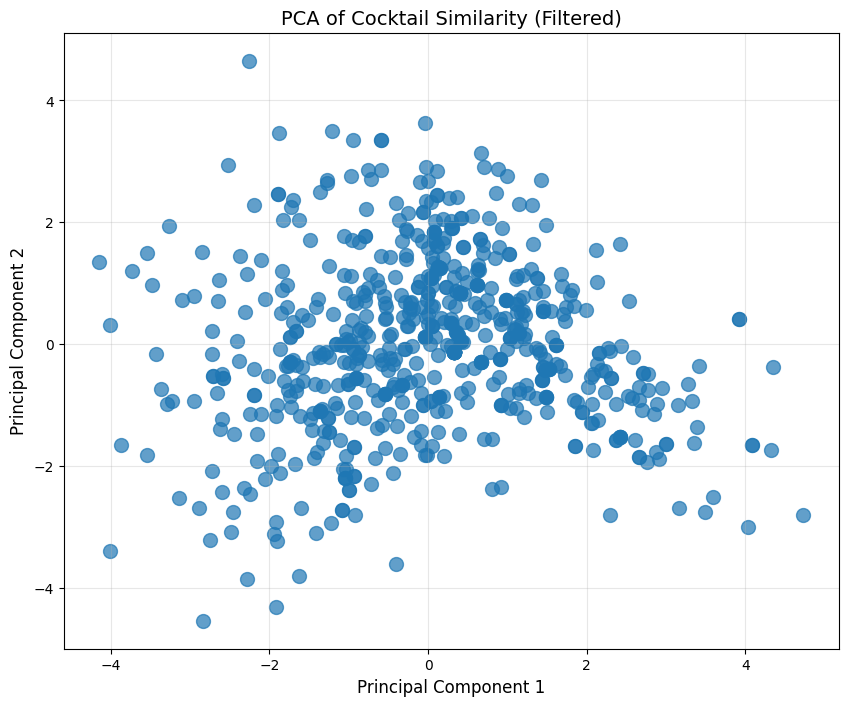

In [5]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

data_matrix = pd.read_csv('cocktail_builder_matrix.csv')

# 計算每個成分的總出現次數
ingredient_counts = data_matrix.iloc[:, 1:].sum(axis=0)  # 跳過 'Cocktail Name'

# 設定門檻，只保留出現次數超過指定值的變數
threshold = 15  # 出現次數的門檻
filtered_columns = ingredient_counts[ingredient_counts > threshold].index

# 篩選矩陣，只保留符合條件的列
filtered_matrix = data_matrix[filtered_columns]

# 將數據標準化（確保數據範圍一致）
from sklearn.preprocessing import StandardScaler
scaled_matrix = StandardScaler().fit_transform(filtered_matrix)

# 執行 PCA
pca = PCA(n_components=2)  # 降為 2 維
pca_result = pca.fit_transform(scaled_matrix)

# 將結果轉為 DataFrame
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=data_matrix['Cocktail Name'])

# 繪製 2D 散點圖
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=100, alpha=0.7)

# 添加標籤
# for cocktail, (x, y) in pca_df.iterrows():
    # plt.text(x, y, cocktail, fontsize=10)

plt.title("PCA of Cocktail Similarity (Filtered)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 33590 (\N{CJK UNIFIED IDEOGRAPH-8336}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USE

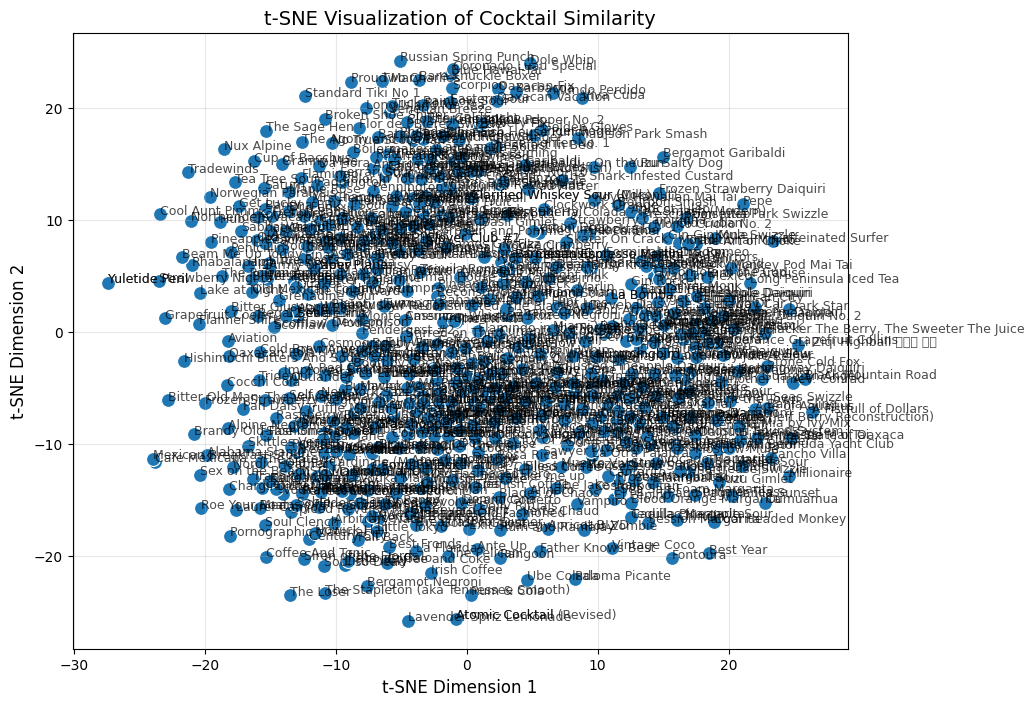

In [24]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 假設 jaccard_similarity_df 是您的相似度矩陣
# 將相似度矩陣轉為距離矩陣（1 - 相似度）
distance_matrix = 1 - jaccard_similarity_df.values

# 設定數據矩陣（剔除雞尾酒名稱列，僅保留二進制成分矩陣）
binary_matrix = data_matrix.set_index('Cocktail Name')

# 使用 t-SNE 降維
# 假設 binary_matrix 是原始的雞尾酒成分二進制矩陣
tsne = TSNE(n_components=2, init="pca", perplexity=50, learning_rate=500, random_state=42)
tsne_result = tsne.fit_transform(binary_matrix)

# 將結果轉為 DataFrame
tsne_df = pd.DataFrame(tsne_result, columns=["TSNE1", "TSNE2"], index=jaccard_similarity_df.index)

# 繪製 2D t-SNE 圖
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", s=100)

# 添加標籤
for cocktail, (x, y) in tsne_df.iterrows():
    plt.text(x, y, cocktail, fontsize=9, alpha=0.7)

plt.title("t-SNE Visualization of Cocktail Similarity", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


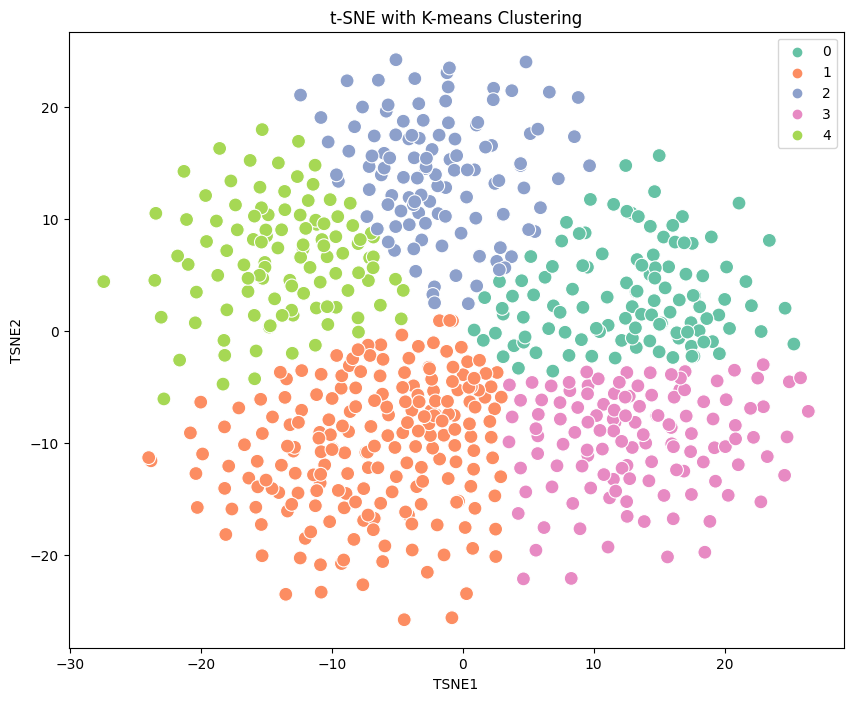

In [25]:
from sklearn.cluster import KMeans

# 基於 t-SNE 的降維結果進行 K-means 聚類
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(tsne_result)

# 繪製含有聚類標籤的 t-SNE 結果
plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_df['TSNE1'], y=tsne_df['TSNE2'], hue=clusters, palette="Set2", s=100)
plt.title("t-SNE with K-means Clustering")
plt.show()
